In [1]:
# Import numpy for arrays and matplotlib for drawing the numbers
import numpy as np

def PCA(x, num):

    # Step 1 - mean centering the data
    x_mean = x - np.mean(x, axis=0)

    # Step 2
    cov_mat = np.cov(x_mean, rowvar=False)

    # Step 3
    eigen_values, eigen_vectors = np.linalg.eigh(cov_mat)

    # Step 4
    sorted_index = np.argsort(eigen_values)[::-1]
    sorted_eigenvalue = eigen_values[sorted_index]
    sorted_eigenvectors = eigen_vectors[:,sorted_index]

    # Step 5 
    eigenvector_subset = sorted_eigenvectors[:,0:num]

    # Step 6
    x_reduced = np.dot(eigenvector_subset.transpose(), x_mean.transpose()).transpose()

    return x_reduced

In [2]:
training_data_file = open("mnist_train.csv",'r')
training_data_list = training_data_file.readlines()
training_data_file.close()

data = []
correct_label = []

for record in training_data_list:
    all_values = record.split(',')
    correct_label.append(int(all_values[0]))
    data.append((np.asfarray(all_values[1:])/255.0*0.99)+0.01)

from sklearn.preprocessing import StandardScaler
standardized_data = StandardScaler().fit_transform(data)
print(standardized_data.shape)

(60000, 784)


In [3]:
#find the co-variance matrix which is : A^T * A
sample_data = standardized_data
# matrix multiplication using numpy
covar_matrix = np.matmul(sample_data.T , sample_data)
print ('The shape of variance matrix = ', covar_matrix.shape)

The shape of variance matrix =  (784, 784)


In [4]:
from scipy.linalg import eigh
# the parameter ‘eigvals’ is defined (low value to heigh value) 
# eigh function will return the eigen values in asending order
# this code generates only the top 2 (782 and 783)(index) eigenvalues.
values, vectors = eigh(covar_matrix, eigvals=(782,783))
print('Shape of eigen vectors = ',vectors.shape)
# converting the eigen vectors into (2,d) shape for easyness of further computations
vectors = vectors.T
print('Updated shape of eigen vectors = ',vectors.shape)
# here the vectors[1] represent the eigen vector corresponding 1st principal eigen vector
# here the vectors[0] represent the eigen vector corresponding 2nd principal eigen vector

Shape of eigen vectors =  (784, 2)
Updated shape of eigen vectors =  (2, 784)


In [5]:
import matplotlib.pyplot as plt
new_coordinates = np.matmul(vectors, sample_data.T)

In [6]:
import pandas as pd
new_coordinates = np.vstack((new_coordinates, correct_label)).T
dataframe = pd.DataFrame(data=new_coordinates, columns=('1st_principal', '2nd_principal', 'label'))
print(dataframe.head())

   1st_principal  2nd_principal  label
0      -4.814790       0.922159    5.0
1      -7.754403      -8.708977    0.0
2       9.431338      -2.328389    4.0
3      -3.746318       6.582173    1.0
4       3.133297       5.183251    9.0


In [7]:
# plotting the 2d data points with seaborn
import seaborn as sn
mpalette = sn.color_palette("ch:s=-.2,r=.6", as_cmap=True)
sn.FacetGrid(dataframe, hue='label', size=6, palette=mpalette).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

c:\Users\User\AppData\Local\Programs\Python\Python37\lib\site-packages\seaborn\axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


TypeError: 'ListedColormap' object is not iterable

In [ ]:
# plotting the 2d data points with seaborn
mpalette = sn.color_palette("cubehelix", as_cmap=True)
sn.FacetGrid(dataframe, hue='label', size=6,palette=mpalette).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

c:\Users\User\AppData\Local\Programs\Python\Python37\lib\site-packages\seaborn\axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


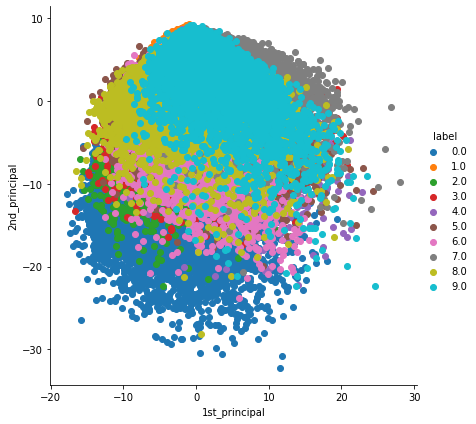

In [ ]:
# plotting the 2d data points with seaborn
mpalette = sn.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
sn.FacetGrid(dataframe, hue='label', size=6, palette=mpalette).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

In [ ]:
# plotting the 2d data points with seaborn
mpalette = sn.color_palette("deep")
sn.FacetGrid(dataframe, hue='label', size=6, palette=mpalette).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

c:\Users\User\AppData\Local\Programs\Python\Python37\lib\site-packages\seaborn\axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


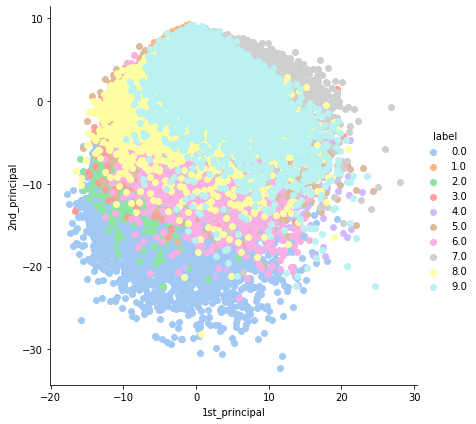

In [ ]:
# plotting the 2d data points with seaborn
mpalette = sn.color_palette("pastel")
sn.FacetGrid(dataframe, hue='label', size=6, palette=mpalette).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()